# Práctico 3 - Expresión Genética Ejercicio 2) - Switch genético

Estudiamos la dinpamica de un sistema de dos genes con represión mutua:

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.integrate import solve_ivp

In [100]:
# Definimos la función de represión
def g_R(p, a, b, c, h):
    return a/(b + c * p**h)


def switch_completo(t, y, alpha_m, beta_m, alpha_p, beta_p, a, b, c, h):
    m1, m2, p1, p2 = y

    dm1dt = alpha_m * g_R(p2, a, b, c, h) - beta_m * m1 # Concentración de mRNA de las especies
    dm2dt = alpha_m * g_R(p1, a, b, c, h) - beta_m * m2
    dp1dt = alpha_p * m1 - beta_p * p1 # Concentración de la proteína de las especies
    dp2dt = alpha_p * m2 - beta_p * p2

    return [dm1dt, dm2dt, dp1dt, dp2dt]

In [101]:
# Habiendo hecho la aproximación de esclavización podemos reducir el sistema
# a solo dos ecuaciones diferenciales
def switch(t, y, alpha_p, beta_p, alpha_m, beta_m, a, b, c, h):
    p1, p2 = y

    dp1dt = alpha_p * (alpha_m/beta_m) * g_R(p2, a, b, c, h) - beta_p * p1
    dp2dt = alpha_p * (alpha_m/beta_m) * g_R(p1, a, b, c, h) - beta_p * p2

    return [dp1dt, dp2dt]

In [102]:
def pi(pj, alpha_m, beta_m, alpha_p, beta_p, a, b, c, h):
    return (alpha_p/beta_p) * (alpha_m/beta_m) * g_R(pj, a, b, c, h)

Estudiamos primero la dinámica con represión conjunta

In [103]:
# Definimos los parámetros del sistema
alpha_m = 40 #nMol/min
beta_m = 1 #1/min
alpha_p = 1 #nMol/min
beta_p = 0.001 #1/min
a = 1
b = 1
c = 1
h = 1

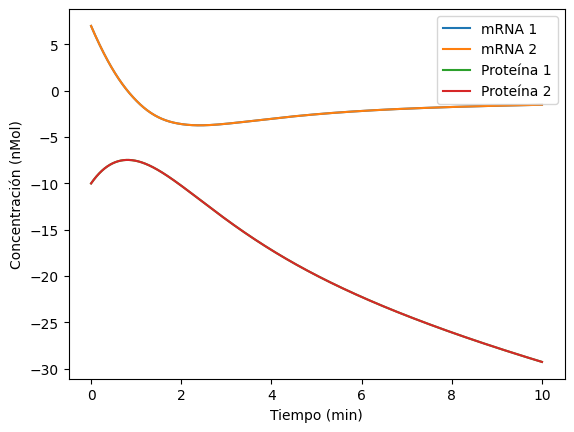

In [104]:
# Definimos las condiciones iniciales
y0 = [7, 7, -10, -10]

# Damos el tiempo de integración
t_span = (0, 10)

# Definimos el tiempo de integración
t = np.linspace(t_span[0], t_span[1], 1000)

# Resolvemos el sistema de ecuaciones diferenciales
sol = solve_ivp(switch_completo, t_span, y0, args=(alpha_m, beta_m, alpha_p, beta_p, a, b, c, h), t_eval=t)

# Graficamos la solución
fig, ax = plt.subplots()
ax.plot(sol.t, sol.y[0], label='mRNA 1')
ax.plot(sol.t, sol.y[1], label='mRNA 2')
ax.plot(sol.t, sol.y[2], label='Proteína 1')
ax.plot(sol.t, sol.y[3], label='Proteína 2')
ax.set_xlabel('Tiempo (min)')
ax.set_ylabel('Concentración (nMol)')
ax.legend()
plt.show()

Para el sisetma simplificado con la condición $\beta_m \gg \beta_p$ tenemos que se produce una transición que depende de los parámetros de la función de represión.

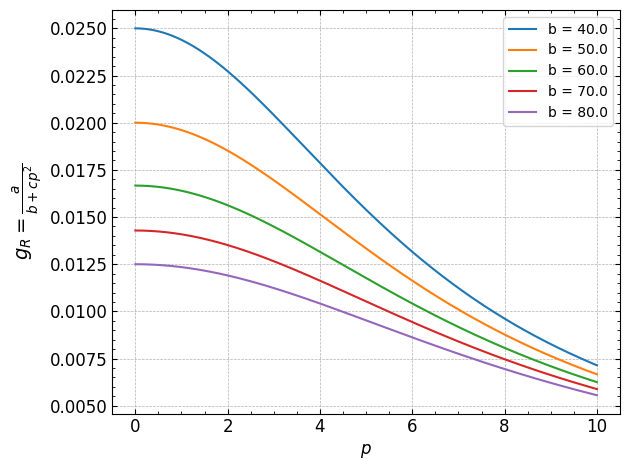

In [202]:
a = 1
bs = np.linspace(40, 80, 5)
c = 1
h = 2

p = np.linspace(0,10, 1000)
for b in bs:
    plt.plot(p, g_R(p, a, b, c, h), label='b = {}'.format(b))

plt.legend()
plt.xlabel('$p$', fontsize = 12)
plt.ylabel('$g_R = \\frac{a}{b+cp^2}$', fontsize=14)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc = 'best')
plt.tight_layout()
plt.savefig('g_R.pdf')
plt.show()

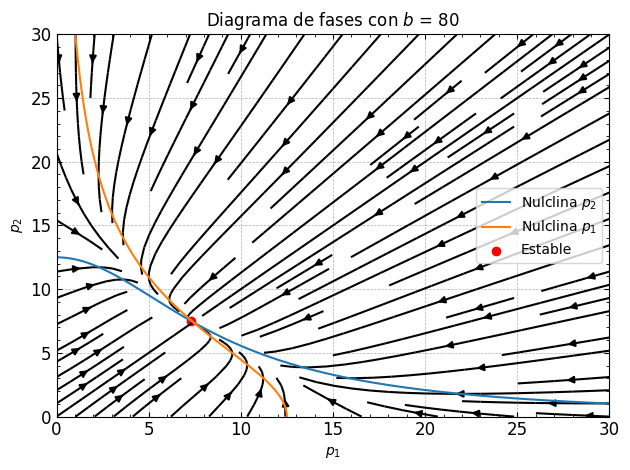

In [203]:
alpha_p = 1
beta_p = 0.001
alpha_m = 1
beta_m = 1
a = 1
b = 80
c = 1
h = 2

# Definimos las condiciones iniciales
y0 = [0.1, 0.1]

# Definimos el tiempo de integración
t = np.linspace(0, 100, 1000)

# Resolvemos las ecuaciones diferenciales
sol = solve_ivp(switch, [t[0], t[-1]], y0, args=(alpha_p, beta_p, alpha_m, beta_m, a, b, c, h), t_eval=t)


# Encontramos
p = np.linspace(0, 30, 2000)
P2, P1 = np.mgrid[0:30:2000j, 0:30:2000j]

dp1dt = alpha_p * (alpha_m/beta_m) * g_R(P2, a, b, c, h) - beta_p * P1
dp2dt = alpha_p * (alpha_m/beta_m) * g_R(P1, a, b, c, h) - beta_p * P2

# Grafiquemos las nulclinas
p1eq = pi(p, alpha_m, beta_m, alpha_p, beta_p, a, b, c, h)
p2eq = pi(p, alpha_m, beta_m, alpha_p, beta_p, a, b, c, h)

fig, ax = plt.subplots()
ax.streamplot(P1, P2, dp1dt, dp2dt, color='black')
ax.plot(p, p2eq, label = 'Nulclina $p_2$')
ax.plot(p1eq, p, label = 'Nulclina $p_1$')
ax.set_xlabel('$p_1$')
ax.set_ylabel('$p_2$')
ax.scatter(7.3,7.5, color = 'red', label = 'Estable')
# ax.scatter(23.5,1.7, color = 'red')
# ax.scatter(8.7,8.7, color = 'blue', label = 'Inestable')
ax.set_title(f'Diagrama de fases con $b$ = {b}')
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc = 'best')
plt.tight_layout()
plt.savefig('switch3.pdf')
plt.show()

Vemos que lo que aparece es una transición de fases en la cual el sistema pasa de tener dos puntos fijos estables y uno inestable a tener un solo punto estable, lo que se conoce como un switch genético puesto que funciona como un interruptor que activa o desactiva la expresión de los genes.